In [1]:
# import libraries
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display # for printing things in LaTex

In [2]:
# ------------------------------------------------------------
# 1. Define symbolic node coordinates (FULL NODE MODEL)
# ------------------------------------------------------------

# Unit 0 nodes
y0B, z0B = sp.symbols('y0B z0B', real=True)  # bottom
y0L, z0L = sp.symbols('y0L z0L', real=True)  # left
y0R, z0R = sp.symbols('y0R z0R', real=True)  # right
y0T, z0T = sp.symbols('y0T z0T', real=True)  # top

# Unit 1 nodes
y1B, z1B = sp.symbols('y1B z1B', real=True)  # bottom
y1L, z1L = sp.symbols('y1L z1L', real=True)  # left
y1R, z1R = sp.symbols('y1R z1R', real=True)  # right
y1T, z1T = sp.symbols('y1T z1T', real=True)  # top

# Node list IMPORTANT: pay attention to order
nodes = [
    sp.Matrix([y0B, z0B]),  # 0 = p0B
    sp.Matrix([y0L, z0L]),  # 1 = p0L
    sp.Matrix([y0R, z0R]),  # 2 = p0R
    sp.Matrix([y0T, z0T]),  # 3 = p0T
    sp.Matrix([y1B, z1B]),  # 4 = p1B
    sp.Matrix([y1L, z1L]),  # 5 = p1L
    sp.Matrix([y1R, z1R]),  # 6 = p1R
    sp.Matrix([y1T, z1T]),  # 7 = p1T
]

# Basic info
N = len(nodes)
dim = 2

print("total nodes:", N)
print("dimensions:", dim)

total nodes: 8
dimensions: 2


In [3]:
# ------------------------------------------------------------
# 2. Define displacement vector u (FULL NODE DOFs)
# ------------------------------------------------------------

u_symbols = []
for i in range(N):
    uiy, uiz = sp.symbols(f'u{i}y u{i}z', real=True)
    u_symbols.extend([uiy, uiz])

u = sp.Matrix(u_symbols)   # shape = (2N, 1)
print("u shape:", u.shape)  # should be (16,1)

u shape: (16, 1)


In [4]:
# ------------------------------------------------------------
# 3. Define shape bonds (constraints)
# ------------------------------------------------------------

shape_bonds = [
    # UNIT 0
    (0, 1),  # bottom → left
    (1, 3),  # left → top
    (3, 2),  # top → right
    (2, 0),  # right → bottom

    # UNIT 1
    (4, 5),  # bottom → left
    (5, 7),  # left → top
    (7, 6),  # top → right
    (6, 4),  # right → bottom

    # vertical spine
    (0, 3),  # unit 0: bottom → top
    (4, 7),  # unit 1: bottom → top
]

print("number of constraints:", len(shape_bonds))

number of constraints: 10


In [ ]:
# ------------------------------------------------------------
# 4. Build compatibility matrix C directly
# ------------------------------------------------------------
#
# recall: C(q)=\frac{\partial \ell(q)}{\partial q}
#   where \ell(q): (for Maxwell-Calladine) is a vector of the active constraints in that configuration
#               q: node positions
#
# for row vector column ordering, recall u_i = [y_i, z_i]^T
#   (so columns corresponding y are at the i indices, and z cols at i+1)
def compatibility_row(i, j, nodes, N):
    '''
    creates the compatability row for the bar connecting node i to node j
    '''
    xi = nodes[i] # get the position vector of node i from the nodes matrix
    xj = nodes[j] #  get the position vector of node j from the nodes matrix

    d = xj - xi # get the distance from node i to node j
    L = sp.sqrt((d.T * d)[0]) # compute the length from node i to node j
    n = d / L # normlize the direction vector

    row = sp.zeros(1, 2 * N) # create an emptry row (row of 0s) of length 2N

    row[0, 2*i]   = -n[0] # set the i columns in row to the z component of n (-)
    row[0, 2*i+1] = -n[1] # set the i+1 columns in row to the y component of n (-)

    row[0, 2*j]   =  n[0] # set the j columns in row to the z component of n
    row[0, 2*j+1] =  n[1] # set the j+1 columns in row to the z component of n
    
    #print("this is your row: ", row)
    
    return row

def fix_y_row(i, N):
    '''
    Build a constraint row preventing node i from moving in the y-direction.
    '''
    row = sp.zeros(1, 2 * N)   # row vector of length 2N
    row[0, 2*i] = 1            # y-DOF for node i lives at column 2*i
    return row


def fix_z_row(i, N):
    '''
    Build a constraint row preventing node i from moving in the z-direction.
    '''
    row = sp.zeros(1, 2 * N)   # row vector of length 2N
    row[0, 2*i + 1] = 1        # z-DOF for node i lives at column 2*i + 1
    return row


# build the bond rows for each (i, j) in shape_bonds
bond_rows = [
    compatibility_row(i, j, nodes, N)
    for (i, j) in shape_bonds
]

# -----------------------------------
# support / grounding constraints
# -----------------------------------
fix_unit_rows = []

# nodes belonging to the bottom unit (Unit 0)
bottom_unit_nodes = [0, 1, 2, 3]

# Instead of fixing every bottom-unit node, use a minimal set of
# support constraints to remove the bottom unit's rigid-body motions:
#   1) translation in y
#   2) translation in z
#   3) rotation
#
# We do that by:
#   - fully fixing one node (anchor node)
#   - fixing one direction on a second node (anti-rotation node)

anchor_node = 0
anti_rotation_node = 3

# fully fix the anchor node: u_0y = 0, u_0z = 0
fix_unit_rows.append(fix_y_row(anchor_node, N))
fix_unit_rows.append(fix_z_row(anchor_node, N))

# kill rigid-body rotation of the bottom unit
# for this geometry, constrain node 3 in y
fix_unit_rows.append(fix_y_row(anti_rotation_node, N))

# -----------------------------------
# guide constraint for the top-bottom pin
# -----------------------------------
# constrain node 4 to vertical motion only:
#   u_4y = 0, but u_4z is free
top_bottom_pin = 4
fix_unit_rows.append(fix_y_row(top_bottom_pin, N))

# -----------------------------------
# combine all active constraints into C
# -----------------------------------
all_rows = bond_rows + fix_unit_rows
C = sp.Matrix.vstack(*all_rows)

# full constraint matrix
C_total = sp.Matrix.vstack(*(bond_rows + fix_unit_rows))

print("C_total shape:", C_total.shape)
print("Rank(C_total):", C_total.rank())
display(C_total)

C_total shape: (14, 16)
Rank(C_total): 14


Matrix([
[-(-y0B + y0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2), -(-z0B + z0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2),  (-y0B + y0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2),  (-z0B + z0L)/sqrt((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                  0,                                                  0,                                                    0,                                                    0,                                                     0,                                                     0,                                                     0,                                                     0,                                                  0,                                                  0,                                                    0,                                                    0],
[                                                    0,                                                     0, -(-y0L + y0T)/

In [19]:
# ------------------------------------------------------------
# 5. Stiffness matrix K (symbolic)
# ------------------------------------------------------------

nb = len(bond_rows)       # number of bond/shape constraint rows
ns = len(fix_unit_rows)    # number of support/guide constraint rows

k_bond = sp.symbols(f'kb0:{nb}', positive=True, real=True)
k_support = sp.symbols(f'ks0:{ns}', positive=True, real=True)

K = sp.diag(*(list(k_bond) + list(k_support)))

print("C_total shape:", C_total.shape)
print("K shape:", K.shape)

# ------------------------------------------------------------
# 6. Symbolic Hessian
# ------------------------------------------------------------

Hess_sym = C_total.T * K * C_total

print("Symbolic Hessian shape:", Hess_sym.shape)
# display(Hess_sym)   # careful: this can get very large

# ------------------------------------------------------------
# 7. Symbolic Hamiltonian
# ------------------------------------------------------------

H_sym = sp.Rational(1, 2) * (u.T * Hess_sym * u)[0]

print("Symbolic Hamiltonian:")
display(H_sym)

print("Symbolic Hessian:")
display(Hess_sym)

C_total shape: (14, 16)
K shape: (14, 14)
Symbolic Hessian shape: (16, 16)
Symbolic Hamiltonian:


u0y*(-kb0*u1y*(-y0B + y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) - kb0*u1z*(-y0B + y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) - kb3*u2y*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2) - kb3*u2z*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) - kb8*u3y*(-y0B + y0T)**2/((-y0B + y0T)**2 + (-z0B + z0T)**2) - kb8*u3z*(-y0B + y0T)*(-z0B + z0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2) + u0y*(kb0*(-y0B + y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) + kb3*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2) + kb8*(-y0B + y0T)**2/((-y0B + y0T)**2 + (-z0B + z0T)**2) + ks0) + u0z*(kb0*(-y0B + y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + kb3*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) + kb8*(-y0B + y0T)*(-z0B + z0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2)))/2 + u0z*(-kb0*u1y*(-y0B + y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) - kb0*u1z*(-z0B + z0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) - kb3*u2y*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) -

Symbolic Hessian:


Matrix([
[                       kb0*(-y0B + y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2) + kb3*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2) + kb8*(-y0B + y0T)**2/((-y0B + y0T)**2 + (-z0B + z0T)**2) + ks0, kb0*(-y0B + y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2) + kb3*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2) + kb8*(-y0B + y0T)*(-z0B + z0T)/((-y0B + y0T)**2 + (-z0B + z0T)**2),                                                                              -kb0*(-y0B + y0L)**2/((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                                    -kb0*(-y0B + y0L)*(-z0B + z0L)/((-y0B + y0L)**2 + (-z0B + z0L)**2),                                                                         -kb3*(y0B - y0R)**2/((y0B - y0R)**2 + (z0B - z0R)**2),                                                                -kb3*(y0B - y0R)*(z0B - z0R)/((y0B - y0R)**2 + (z0B - z0R)**2),                                                                     

In [ ]:
# ------------------------------------------------------------
# Introduce real system (2D 2unit RAMMs Chain)
# ------------------------------------------------------------
# 2unit chain sample:
# bottom of unit 0 is at 0,0
# bottom of unit 1 is at 10,0 (half dist unit 0)
geom_ref = {
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R:  8,  z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 10,
    y1L: -8,  z1L: 20,
    y1R:  8,  z1R: 20,
    y1T: 0,   z1T: 30,
}

C_num = C_total.subs(geom_ref)
print("Rank(C):", C_num.rank())

Rank(C): 14


In [29]:
# ------------------------------------------------------------
# Get the stiffness matrix for the real system
# ------------------------------------------------------------

nb = len(shape_bonds)
ns = len(l_q) - nb

k_bond = sp.symbols(f'kb0:{nb}', positive=True, real=True)
k_support = sp.symbols(f'ks0:{ns}', positive=True, real=True)

K = sp.diag(*(list(k_bond) + list(k_support)))

# substitute numerical stiffnesses
k_subs = {}

for kv in k_bond:
    k_subs[kv] = 1   # bond stiffness

for kv in k_support:
    k_subs[kv] = 1   # support stiffness (or make this large, e.g. 1000)

K_num = K.subs(k_subs)

print("C_num shape:", C_num.shape)
print("K_num shape:", K_num.shape)

C_num shape: (14, 16)
K_num shape: (14, 14)


In [30]:
# ------------------------------------------------------------
# Get the Hessian (Hess = C^T K C) for the real system
# ------------------------------------------------------------

Hess = C_num.T * K_num * C_num

print("Hessian shape:", Hess.shape)
print("Numeric Hessian:")
display(Hess)

Hessian shape: (16, 16)
Numeric Hessian:


Matrix([
[ 73/41,      0, -16/41,  20/41, -16/41, -20/41,      0,      0,      0,      0,      0,      0,      0,      0,      0,      0],
[     0, 132/41,  20/41, -25/41, -20/41, -25/41,      0,     -1,      0,      0,      0,      0,      0,      0,      0,      0],
[-16/41,  20/41,  32/41,      0,      0,      0, -16/41, -20/41,      0,      0,      0,      0,      0,      0,      0,      0],
[ 20/41, -25/41,      0,  50/41,      0,      0, -20/41, -25/41,      0,      0,      0,      0,      0,      0,      0,      0],
[-16/41, -20/41,      0,      0,  32/41,      0, -16/41,  20/41,      0,      0,      0,      0,      0,      0,      0,      0],
[-20/41, -25/41,      0,      0,      0,  50/41,  20/41, -25/41,      0,      0,      0,      0,      0,      0,      0,      0],
[     0,      0, -16/41, -20/41, -16/41,  20/41,  73/41,      0,      0,      0,      0,      0,      0,      0,      0,      0],
[     0,     -1, -20/41, -25/41,  20/41, -25/41,      0,  91/41,      0,      0, 

In [31]:
# ---------------------------------------------------------------
# Use Maxwell-Calladine Framework to analyze the real system
# ---------------------------------------------------------------
#
# M-C Formula: dN -  rank = #LZM - #SSS
#   where:
#       dN = number of degreees of freedom
#       rank = number of active constraints 
#       #LZM = number of linear zero modes (* what we're solving for)
#           also M (mechanisms) or remaining DoFs after constraints are applied
#       #SSS = states of self stress
#
Nc = C_num.shape[0]
dN = C_num.shape[1]
rank = C_num.rank()

M = dN - rank
S = Nc - rank

print("\n==========================")
print("Maxwell-Calladine Analysis")
print("============================")
print("dN (total DOFs):", dN)
print("Nc (constraints):", Nc)
print("Rank(C):", rank)
print()
print("Mechanisms (M):", M)
print("States of self-stress (S):", S)
print()
print("Check: M - S =", M - S)
print("Expected:", dN - Nc)

# i think this system doesnt constrain bottom unit fully; it can still rotate so 3 mechanisms


Maxwell-Calladine Analysis
dN (total DOFs): 16
Nc (constraints): 14
Rank(C): 14

Mechanisms (M): 2
States of self-stress (S): 0

Check: M - S = 2
Expected: 2


Sampled-grid minimum:
a_min = 0.0
b_min = 0.0
H_min = 0.0


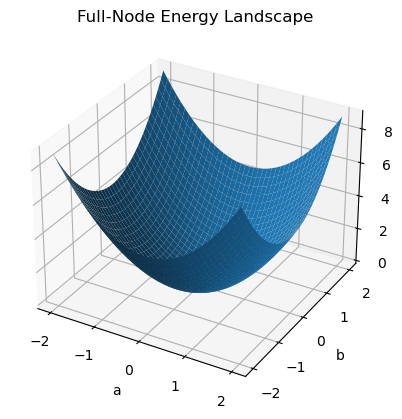

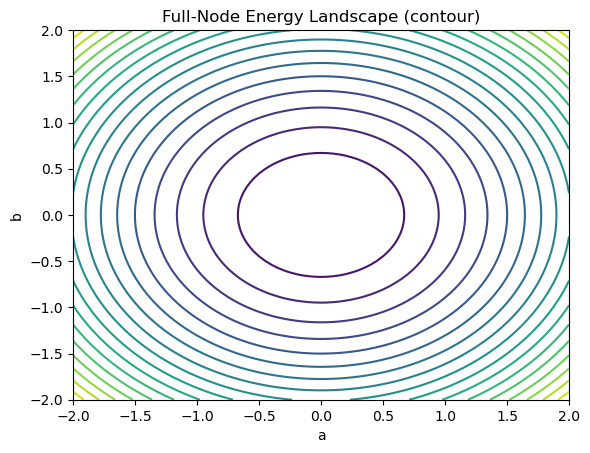

In [13]:
def make_u(pairs):
    """
    pairs = [(uy0, uz0), (uy1, uz1), ...] for 8 nodes
    returns 16x1 displacement vector
    """
    flat = []
    for uy, uz in pairs:
        flat.extend([uy, uz])
    return sp.Matrix(flat)

def plot_energy_landscape_full(Hess_num, u_dir1, u_dir2, title="Energy Landscape"):
    """
    Plot H(a,b) = 1/2 * u(a,b)^T Hess_num u(a,b)
    where u(a,b) = a*u_dir1 + b*u_dir2
    """
    import numpy as np
    import matplotlib.pyplot as plt

    H_np = np.array(Hess_num.evalf(), dtype=float) # TODO: use this without code above
    d1 = np.array(u_dir1, dtype=float).reshape(-1, 1)
    d2 = np.array(u_dir2, dtype=float).reshape(-1, 1)

    a_vals = np.linspace(-2, 2, 81)
    b_vals = np.linspace(-2, 2, 81)

    A, B = np.meshgrid(a_vals, b_vals)
    E = np.zeros_like(A, dtype=float)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            u_ab = A[i, j] * d1 + B[i, j] * d2
            E[i, j] = 0.5 * float(u_ab.T @ H_np @ u_ab)

    min_idx = np.unravel_index(np.argmin(E), E.shape)
    print("Sampled-grid minimum:")
    print("a_min =", A[min_idx])
    print("b_min =", B[min_idx])
    print("H_min =", E[min_idx])

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A, B, E)
    ax.set_xlabel("a")
    ax.set_ylabel("b")
    ax.set_zlabel("H")
    ax.set_title(title)
    plt.show()

    plt.figure()
    plt.contour(A, B, E, levels=20)
    plt.xlabel("a")
    plt.ylabel("b")
    plt.title(title + " (contour)")
    plt.show()

# move top node of unit 0 up
u_dir1 = make_u([
    (0, 0),   # node 0
    (0, 0),   # node 1
    (0, 0),   # node 2
    (0, 1),   # node 3
    (0, 0),   # node 4
    (0, 0),   # node 5
    (0, 0),   # node 6
    (0, 0),   # node 7
])

# move top node of unit 1 up
u_dir2 = make_u([
    (0, 0),   # node 0
    (0, 0),   # node 1
    (0, 0),   # node 2
    (0, 0),   # node 3
    (0, 0),   # node 4
    (0, 0),   # node 5
    (0, 0),   # node 6
    (0, 1),   # node 7
])

plot_energy_landscape_full(Hess, u_dir1, u_dir2, title="Full-Node Energy Landscape")